# 1. Generate 2D dataset

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [8]:
def Show_data2D(x):
    plt.plot(np.arange(L),x[0, :, 0], label='sample 0', c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 0], label='sample 1', c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 0], label='sample 2', c='b')
    plt.plot(np.arange(3*L,4*L),x[3, :, 0], label='sample 3', c='g')
    plt.plot(np.arange(4*L,5*L),x[4, :, 0], label='sample 4', c='orange')
    plt.plot(np.arange(5*L,6*L),x[5, :, 0], label='sample 5', c='lightblue')
    plt.plot(np.arange(L),x[0, :, 1], c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 1], c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 1], c='b')
    plt.plot(np.arange(3*L,4*L),x[3, :, 1], c='g')
    plt.plot(np.arange(4*L,5*L),x[4, :, 1], c='orange')
    plt.plot(np.arange(5*L,6*L),x[5, :, 1], c='lightblue')
    
    plt.legend()
    plt.title("Time series")
    plt.show()

In [3]:
# random seed for reproducibility
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]
# rumore non lineare????

In [4]:
def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.cos((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [6]:
# pattern parameters: Z=nr of steps, A=amplitude
Z1 = 12
Z2 = 20

N=10000
L=60

DX1 = 50 
bias1 = 5 
DX2 = 50
bias2 = 10

# run only to generate data
'''
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L,2))

for A1 in range(0, 500, 50):
    for A2 in range(0, 500, 50):
        str0 = f'ts_L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}'
        print(str0)
        
        for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%6 # assign class labels (0,1,2,3,4,5,6)
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j02 = np.random.randint(0,L-1-Z2) 
                    sign = 3-2*y[i] 
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 1 -> 0 +
                    # 2 -> 0 -
                elif y[i]<5:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    sign = 3-2*(y[i]-2)
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 3 -> + +
                    # 4 -> + -
                else:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 5 -> - -
                    
    
        fname='DATA_NEW/x_'+str0
        np.save(fname,x)
        fname='DATA_NEW/y_'+str0
        np.save(fname,y)
'''

ts_L60_Z1(12)_Z2(20)_A1(0)_A2(0)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(50)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(100)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(150)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(200)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(250)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(300)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(350)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(400)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(0)_A2(450)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(50)_A2(0)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(50)_A2(50)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(50)_A2(100)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(50)_A2(150)_DX((50, 50))_bias((5, 10))_N10000
ts_L60_Z1(12)_Z2(20)_A1(50)_A2(200)_

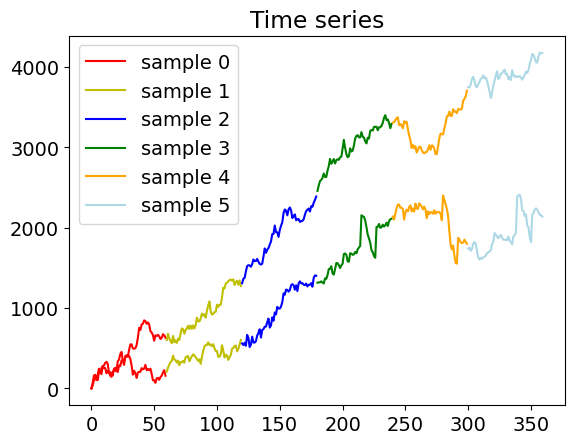

In [9]:
# visualizing data
x = np.load("DATA_NEW/x_ts_L60_Z1(12)_Z2(20)_A1(350)_A2(50)_DX((50, 50))_bias((5, 10))_N10000.npy")
Show_data2D(x)

# 3. Amplitude

In [11]:
def build_model(L, n_class=6, NF=5, l2_reg=0.2, stddev=0.05):
    
    input_shape = (L, 2)
    
    reg = tf.keras.regularizers.l2(l2_reg)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=stddev, seed=None)
    
    model = Sequential([
        Conv1D(filters=NF, kernel_size=11,
               kernel_initializer=ini,
               kernel_regularizer=reg,
               activation='relu',
               input_shape=input_shape),
        AveragePooling1D(5),
        Conv1D(filters=5, kernel_size=7, activation='relu'),
        Flatten(),
        Dense(12, activation='relu'),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])
    
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )
    
    return model


In [12]:
# TRAINING OF THE CNN OVER DIFFERENT DATASETS
BATCH_SIZE = 200
EPOCHS = 150
best_acc = 0
j = 0
models = []
acc = []
n_class = 6

for A1 in range(0, 500, 50):
    for A2 in range(0, 500, 50):
        model = build_model(60)
        str0 = f'ts_L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}'
        fnamex='DATA_NEW/x_'+str0+'.npy'
        fnamey='DATA_NEW/y_'+str0+'.npy'
        
        x = np.load(fnamex)
        
        N,L = len(x), len(x[0])
    
        categ = np.load(fnamey)
        
        y = np.zeros((N,n_class))
        for i in range(N):
            y[i][int(categ[i])] = 1. # y contains one-hot encoding
    
    
        # split into training and validation sets
        perc_train=0.8
        N_train = int(perc_train*N)
        x_train = x[:N_train]
        
        y_train = y[:N_train]
        x_val = x[N_train:]
        y_val = y[N_train:]
        N_val = len(x_val)
        
         
        #remove average value of each sample from its values
        xm_train = x_train.mean(axis=1)
        std_train = x_train.std(axis=1)
        xm_val = x_val.mean(axis=1)
        std_val = x_val.std(axis=1)
        
        # rescale with variance on the training set
        for i in range(N_train):
             x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
        for i in range(N_val):
            x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
        
        x_train = x_train.reshape(x_train.shape[0], L, 2)
        x_val =  x_val.reshape(x_val.shape[0], L, 2)
    
        fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True) 
        
        models.append(fit)    
        acc.append(fit.history['val_accuracy'][-1])
        
        if fit.history['val_accuracy'][-1] > best_acc:
            best_acc = fit.history['val_accuracy'][-1]
            best_model = fit
            best_A = (A1,A2)
    
        print(f"Training dataset: {j}")
        j+=1
        

/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-10 11:07:15.590975: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training dataset: 0
Training dataset: 1
Training dataset: 2
Training dataset: 3
Training dataset: 4
Training dataset: 5
Training dataset: 6
Training dataset: 7
Training dataset: 8
Training dataset: 9
Training dataset: 10
Training dataset: 11
Training dataset: 12
Training dataset: 13
Training dataset: 14
Training dataset: 15
Training dataset: 16
Training dataset: 17
Training dataset: 18
Training dataset: 19
Training dataset: 20
Training dataset: 21
Training dataset: 22
Training dataset: 23
Training dataset: 24
Training dataset: 25
Training dataset: 26
Training dataset: 27
Training dataset: 28
Training dataset: 29
Training dataset: 30
Training dataset: 31
Training dataset: 32
Training dataset: 33
Training dataset: 34
Training dataset: 35
Training dataset: 36
Training dataset: 37
Training dataset: 38
Training dataset: 39
Training dataset: 40
Training dataset: 41
Training dataset: 42
Training dataset: 43
Training dataset: 44
Training dataset: 45
Training dataset: 46
Training dataset: 47
Tr

In [24]:
import os
acc_m = np.array(acc).reshape(10,10)
print("Amplitude that determines the best performance of the CNN: ", best_A)

np.save("Accuracy.npy",acc)

Amplitude that determines the best performance of the CNN:  (400, 450)


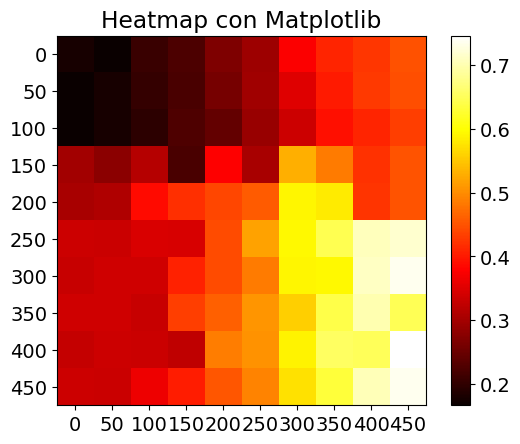

In [14]:
acc_m = np.array(acc).reshape(10,10)


plt.imshow(acc_m, cmap='hot', interpolation='nearest')
plt.xticks(np.arange(0,10), np.arange(0,500,50))
plt.yticks(np.arange(0,10), np.arange(0,500,50))
plt.colorbar()
plt.title("Heatmap con Matplotlib")
plt.show()

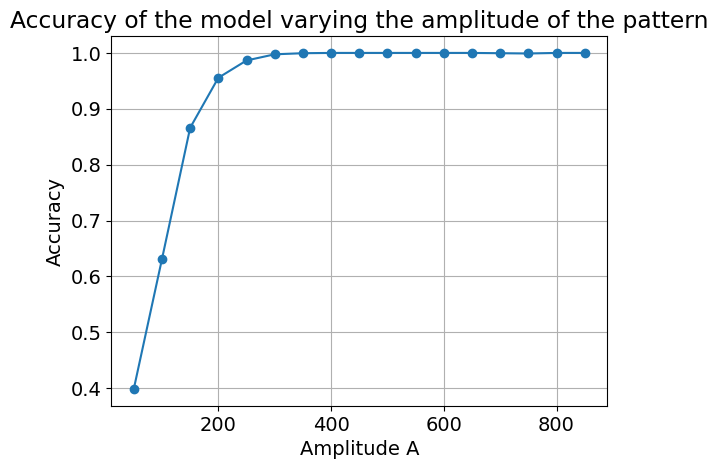

In [37]:
'''
plt.plot(np.arange(50, 900, 50), acc, marker='o')
plt.xlabel("Amplitude A")
plt.ylabel("Accuracy")
plt.title("Accuracy of the model varying the amplitude of the pattern")
plt.grid()
plt.show()

'''

In [15]:
def snr_mf(A,T,sigma):
    delta = A**2/T
    return ((np.pi)**3)/(2*(np.pi + 4))*(delta)/(sigma**2)

def snr_tot(A1, T1, sigma1, A2, T2, sigma2):
    snr_1 = snr_mf(A1, T1, sigma1)
    snr_2 = snr_mf(A2, T2, sigma2)
    
    return snr_1+snr_2

In [16]:
SNR_mf1 = []
SNR_mf2 = []
SNR = []
for A1 in range(0,500,50):
    for A2 in range(0,500,50):
        SNR_mf1.append(snr_mf(A1,Z1,DX1))
        SNR_mf2.append(snr_mf(A2,Z2,DX2))
        SNR.append(snr_tot(A1, Z1, DX1, A2, Z2, DX2))

for x, y in zip(SNR, acc):
    print(x, y)

0.0 0.17800000309944153
0.10854118326363166 0.1665000021457672
0.43416473305452663 0.20800000429153442
0.976870649372685 0.22499999403953552
1.7366589322181065 0.26649999618530273
2.713529581590792 0.2944999933242798
3.90748259749074 0.37700000405311584
5.318517979917952 0.4099999964237213
6.946635728872426 0.42649999260902405
8.791835844354166 0.4490000009536743
0.1809019721060528 0.16750000417232513
0.28944315536968446 0.17949999868869781
0.6150667051605794 0.2029999941587448
1.1577726214787378 0.2214999943971634
1.9175609043241593 0.2615000009536743
2.894431553696845 0.29649999737739563
4.088384569596792 0.35199999809265137
5.499419952024005 0.40149998664855957
7.127537700978479 0.42750000953674316
8.972737816460219 0.4465000033378601
0.7236078884242112 0.1665000021457672
0.8321490716878428 0.1784999966621399
1.1577726214787378 0.1965000033378601
1.7004785377968963 0.226500004529953
2.4602668206423175 0.2434999942779541
3.437137470015003 0.289000004529953
4.631090485914951 0.3350000

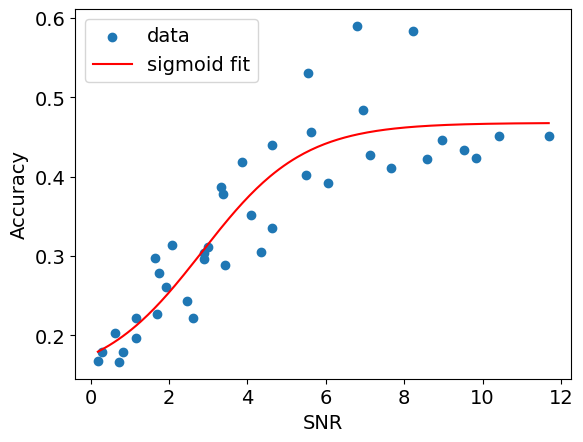

In [19]:
def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k*(x-x0))) + b

xdata = np.array(SNR)[10:50]
ydata = np.array(acc)[10:50]

p0 = [1, np.median(xdata), 1, 0]

popt, pcov = curve_fit(sigmoid, xdata, ydata, p0)

xfit = np.linspace(min(xdata), max(xdata), 200)
yfit = sigmoid(xfit, *popt)

plt.scatter(xdata, ydata, label='data')
plt.plot(xfit, yfit, label='sigmoid fit', color = 'r')
plt.xlabel('SNR')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



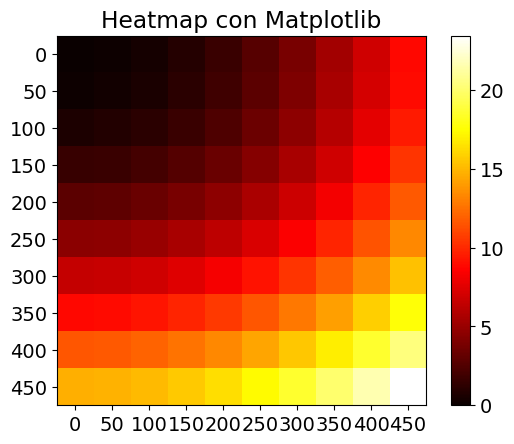

In [20]:
SNR_m = np.array(SNR).reshape(10,10)


plt.imshow(SNR_m, cmap='hot', interpolation='nearest')
plt.xticks(np.arange(0,10), np.arange(0,500,50))
plt.yticks(np.arange(0,10), np.arange(0,500,50))
plt.colorbar()
plt.title("Heatmap con Matplotlib")
plt.show()